In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [7]:
from pathlib import Path

def find_repo_file(*parts):
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        candidate = base.joinpath(*parts)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(parts)

DATA_FILE = find_repo_file('05_machine_learning', '03_ml_data', 'tabular_datasets', '../03_ml_data/tabular_datasets/bike_train.csv')
df = pd.read_csv(DATA_FILE)

print(df.shape)
df.head()

(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


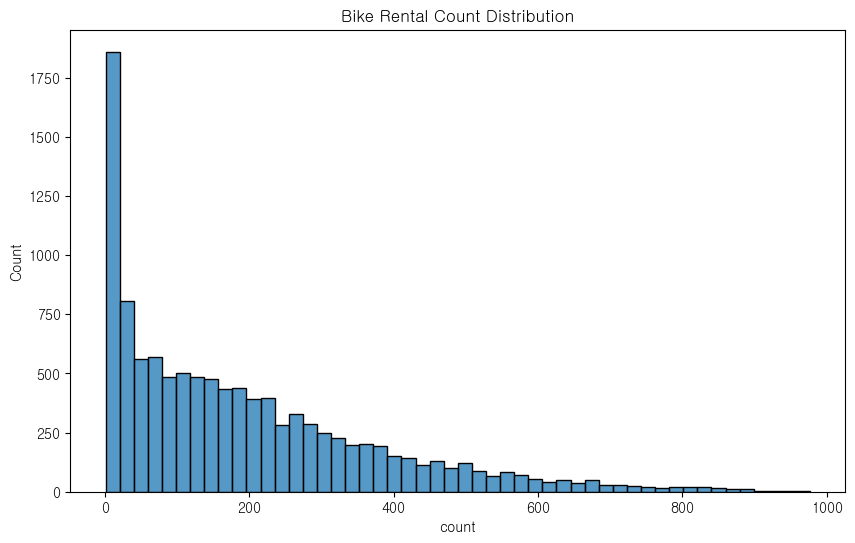

In [9]:
sns.histplot(df["count"], bins=50)
plt.title("Bike Rental Count Distribution")
plt.show()

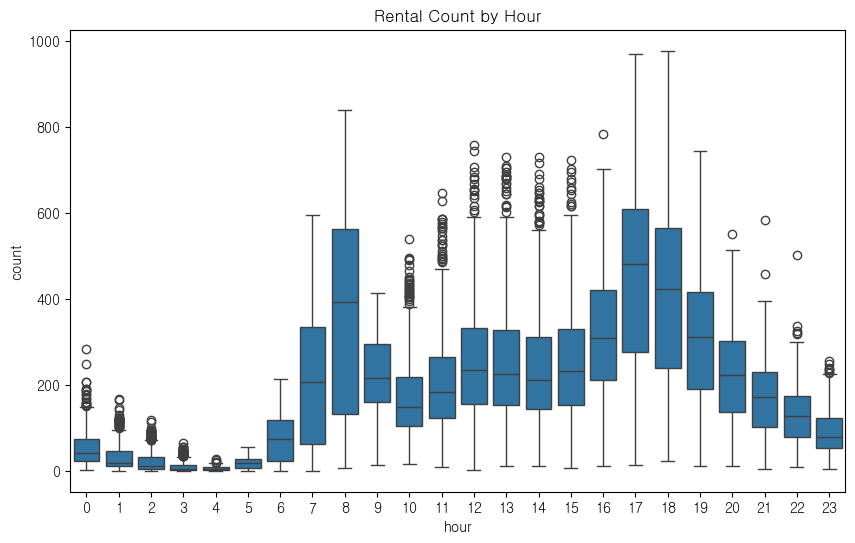

In [10]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["hour"] = df["datetime"].dt.hour

sns.boxplot(x="hour", y="count", data=df)
plt.title("Rental Count by Hour")
plt.show()

In [11]:
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday

In [12]:
df = df.drop(columns=["datetime"])

In [14]:
df = df.drop(columns=["casual", "registered"])

In [15]:
df["log_count"] = np.log1p(df["count"])

In [16]:
X = df.drop(columns=["count","log_count"])
y = df["log_count"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
def rmsle(y, pred):
    log_y = np.log1p(y)
    log_pred = np.log1p(pred)
    squared_error = (log_y - log_pred) ** 2
    return np.sqrt(np.mean(squared_error))

def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))

def evaluate_regr(y, pred):
    rmsle_val = rmsle(y, pred)
    rmse_val  = rmse(y, pred)
    mae_val   = mean_absolute_error(y, pred)

    print(f"RMSLE: {rmsle_val:.3f}")
    print(f"RMSE : {rmse_val:.3f}")
    print(f"MAE  : {mae_val:.3f}")

In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

pred_lr = np.expm1(pred_lr)

evaluate_regr(np.expm1(y_test), pred_lr)

RMSLE: 1.024
RMSE : 160.741
MAE  : 108.131


In [20]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

pred_rf = np.expm1(pred_rf)

evaluate_regr(np.expm1(y_test), pred_rf)

RMSLE: 0.301
RMSE : 39.650
MAE  : 24.113


In [21]:
gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

pred_gb = np.expm1(pred_gb)

evaluate_regr(np.expm1(y_test), pred_gb)

RMSLE: 0.297
RMSE : 41.951
MAE  : 25.882


In [22]:
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

pred_xgb = np.expm1(pred_xgb)

evaluate_regr(np.expm1(y_test), pred_xgb)

RMSLE: 0.281
RMSE : 38.605
MAE  : 23.654


In [23]:
lgb = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_train, y_train)

pred_lgb = lgb.predict(X_test)

pred_lgb = np.expm1(pred_lgb)

evaluate_regr(np.expm1(y_test), pred_lgb)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000502 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 294
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 13
[LightGBM] [Info] Start training from score 4.593780
RMSLE: 0.271
RMSE : 36.652
MAE  : 22.350


In [24]:
results = {
    "LinearRegression": rmse(np.expm1(y_test), pred_lr),
    "RandomForest": rmse(np.expm1(y_test), pred_rf),
    "GradientBoosting": rmse(np.expm1(y_test), pred_gb),
    "XGBoost": rmse(np.expm1(y_test), pred_xgb),
    "LightGBM": rmse(np.expm1(y_test), pred_lgb),
}

pd.Series(results).sort_values()

LightGBM             36.651644
XGBoost              38.605287
RandomForest         39.650454
GradientBoosting     41.950546
LinearRegression    160.741438
dtype: float64

In [27]:
print(X.columns)

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'hour', 'year', 'month', 'day', 'weekday'],
      dtype='str')
